## L1-Penalized GP with Bilby

Posterior:
$$p(\beta, \tau^2, \sigma^2_N, \sigma^2_{GP}, \ell, \lambda \mid y) \propto p(y | \beta, \sigma^2_N, \sigma^2_{GP}, \ell) \times p(\beta | \sigma^2_N, \tau^2) \times \prod_{j=1}^p p(\tau_j^2 | \lambda) \times p(\sigma^2_N) \times p(\sigma^2_{GP}) \times p(\ell) \times p(\lambda)$$

\begin{align*}
& p(y, \beta, \tau^2, \sigma^2_N, \sigma^2_{GP}, \ell, \lambda) \\
&= \frac{\exp\!\left(
 -\frac12 (y - X\beta)^\top (K + \sigma^2_N I_n)^{-1} (y - X\beta)
\right)}
{\sqrt{(2\pi)^n |K + \sigma^2_N I_n|}} \\[6pt]
&\quad \times \frac{\exp\!\left(-\frac12 \beta^\top (\sigma^2_N D_\tau)^{-1} \beta \right)}
{(2\pi)^{p/2} |\sigma^2_N D_\tau|^{1/2}} \\[6pt]
&\quad \times \prod_{j=1}^p \frac{\lambda^2}{2} \exp\!\left( -\frac{\lambda^2}{2} \tau_j^2 \right) \\[6pt]
&\quad \times \frac{\beta_{\text{noise}}^{\alpha_{\text{noise}}}}{\Gamma(\alpha_{\text{noise}})}
(\sigma^2_N)^{-\alpha_{\text{noise}}-1} \exp\!\left( -\frac{\beta_{\text{noise}}}{\sigma^2_N} \right) \\[6pt]
&\quad \times \frac{\beta_{\text{GP}}^{\alpha_{\text{GP}}}}{\Gamma(\alpha_{\text{GP}})}
(\sigma^2_{GP})^{-\alpha_{\text{GP}}-1} \exp\!\left( -\frac{\beta_{\text{GP}}}{\sigma^2_{GP}} \right) \\[6pt]
&\quad \times \frac{1}{\ell \, \sigma_\ell \sqrt{2\pi}}
\exp\!\left( -\frac{(\log \ell - \mu_\ell)^2}{2\sigma_\ell^2} \right) \\[6pt]
&\quad \times \frac{b_\lambda^{a_\lambda}}{\Gamma(a_\lambda)} \lambda^{a_\lambda - 1} e^{-b_\lambda \lambda}
\end{align*}

Log Likelihoods:

1. GP Likelihood


$$\log p(y \mid \beta, \sigma^2_N, \sigma^2_{GP}, \ell)
= -\tfrac{n}{2}\log(2\pi)
-\tfrac{1}{2}\log\!\big| K(\ell,\sigma^2_{GP}) + \sigma^2_N I_n \big|
-\tfrac{1}{2}(y - X\beta)^\top \big( K + \sigma^2_N I_n \big)^{-1}(y - X\beta)$$


2. $\beta \mid \tau^2, \sigma^2_N$

$$\log p(\beta \mid \tau^2, \sigma^2_N)
= -\tfrac{p}{2}\log(2\pi)
-\tfrac{1}{2}\log\!\big|\sigma^2_N D_\tau\big|
-\tfrac{1}{2}\beta^\top (\sigma^2_N D_\tau)^{-1}\beta$$

3. $\tau_j^2 \mid \lambda$

$$\log p(\tau^2 \mid \lambda)
= \sum_{j=1}^p \left[ \log\!\Big(\tfrac{\lambda^2}{2}\Big) - \tfrac{\lambda^2}{2}\tau_j^2 \right]
= p \log\!\Big(\tfrac{\lambda^2}{2}\Big) - \tfrac{\lambda^2}{2}\sum_{j=1}^p \tau_j^2$$

4. $\sigma^2_N$

$$\log p(\sigma^2_N)
= \alpha_{\text{noise}} \log \beta_{\text{noise}}
- \log \Gamma(\alpha_{\text{noise}})
- (\alpha_{\text{noise}} + 1)\log \sigma^2_N
- \tfrac{\beta_{\text{noise}}}{\sigma^2_N}$$

5. $\sigma^2_{GP}$

$$\log p(\sigma^2_{GP})
= \alpha_{\text{GP}} \log \beta_{\text{GP}}
- \log \Gamma(\alpha_{\text{GP}})
- (\alpha_{\text{GP}} + 1)\log \sigma^2_{GP}
- \tfrac{\beta_{\text{GP}}}{\sigma^2_{GP}}$$

6. $\ell$

$$\log p(\ell)
= -\log\!\big(\ell \, \sigma_\ell \sqrt{2\pi}\big)
- \frac{(\log \ell - \mu_\ell)^2}{2\sigma_\ell^2}$$

7. $\lambda$

$$\log p(\lambda)
= a_\lambda \log b_\lambda
- \log \Gamma(a_\lambda)
+ (a_\lambda - 1)\log \lambda
- b_\lambda \lambda$$


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import bilby
from bilby.core.utils import random
import json
import scipy.special
import scipy.stats as stats

# set up
random.seed(123)
label = "penalizedGP"
outdir = "outdir2"
bilby.utils.check_directory_exists_and_if_not_mkdir(outdir)

sample_dat_path = "../synthetic_data/N11000_AP10_noise0.5_seed1/Size500/Rep3.csv"
sample_dat = pd.read_csv(sample_dat_path)

val_dat_path = "../synthetic_data/N11000_AP10_noise0.5_seed1/N11000_AP10_noise0.5_seed1_meta.json"
with open(val_dat_path, 'r') as f:
    val_dat = json.load(f)

true_betas = np.array(val_dat['beta'])
true_ells = np.array(val_dat['lengthscales'])
active_dims = np.array(val_dat['active_indices'])
true_sigma_noise = val_dat['noise_constant']

from sklearn.model_selection import train_test_split

X = sample_dat.iloc[:, :-1].values  #all columns except the last
y = sample_dat.iloc[:, -1].values   #last column

Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=22)

In [22]:
# helper function to compute the RBF kernel
def rbf_kernel(X, ell, sigma_gp):
    N = X.shape[0]
    K = np.zeros((N, N))
    for i in range(N):
        for j in range(N):
            diff = X[i] - X[j] / ell
            K[i, j] = sigma_gp**2 * np.exp(-0.5 * np.dot(diff, diff))
    return K

In [23]:
# custom inverse gamma prior for bilby
class InverseGammaPrior(bilby.core.prior.Prior):
    def __init__(self, alpha, beta, name="inverse_gamma", latex_label=None, unit=None):
        super().__init__(name=name, latex_label=latex_label, unit=unit)
        self.alpha = alpha
        self.beta = beta

    def prob(self, x):
        return stats.invgamma.pdf(x, a=self.alpha, scale=self.beta)

    def ln_prob(self, x):
        return stats.invgamma.logpdf(x, a=self.alpha, scale=self.beta)

In [24]:
# custom likelihood for penalized GP regression

class PenalizedGPLikelihood(bilby.Likelihood):
    def __init__(self, X, y):
        # store data
        self.X = np.asarray(X)
        self.y = np.asarray(y)

        # define parameters
        parameters = {}

        # linear coefficients (betas)
        for i in range(self.X.shape[1]):
            parameters[f"beta{i}"] = None

        # variance parameters (tau^2)
        for i in range(self.X.shape[1]):
            parameters[f"tau_sq_{i}"] = None

        # noise parameters
        parameters["sigma_noise"] = None
        parameters["sigma_gp"] = None
        
        # lengthscales (ells)
        for i in range(self.X.shape[1]):
            parameters[f"ell{i}"] = None

        # lambda (for L1 regularization)
        parameters["lambda"] = None
        
        super().__init__(parameters=parameters)


    def log_likelihood(self):

        # extract parameters
        betas = np.array([self.parameters[f"beta{i}"] for i in range(self.X.shape[1])])
        tau_sqs = np.array([self.parameters[f"tau_sq_{i}"] for i in range(self.X.shape[1])])
        sigma_noise = self.parameters["sigma_noise"]
        sigma_gp = self.parameters["sigma_gp"]
        ells = np.array([self.parameters[f"ell{i}"] for i in range(self.X.shape[1])])
        lbda = self.parameters["lambda"]
        
        # calculate n and p
        n = self.X.shape[0]
        p = self.X.shape[1]

        # calculate covariance matrix C
        C = rbf_kernel(self.X, ells, sigma_gp)
        
        # calculate residuals
        residuals = self.y - self.X @ betas

        # calculate diagonal matrix D
        D = np.diag(tau_sqs)


        # log likelihood components

        # GP likelihood
        log_lik_gp = ( # more stable for computation
            -0.5 * n * np.log(2 * np.pi) 
            -0.5 * np.linalg.slogdet(C + sigma_noise**2 * np.eye(n))[1]
            -0.5 *(residuals).T @ np.linalg.solve(C + sigma_noise**2 * np.eye(n), residuals))

        # beta (vector)
        log_lik_beta = (
            -0.5 * p * np.log(2 * np.pi)
            -0.5 * np.linalg.slogdet(sigma_noise**2 * D)[1]
            -0.5 * betas.T @ np.linalg.solve(sigma_noise**2 * D, betas)
        )
        
        ## check over this part
        # tau_sqs (vector)
        log_lik_tau = (
            p * np.log(lbda**2 / 2.0)
            - 0.5 * lbda**2 * np.sum(tau_sqs)
        )

        # sigma_noise (scalar): coming from inverse-gamma distribution with alpha=?, beta=?
        self.alpha_noise = 1.0
        self.beta_noise = 1.0
        log_lik_sigma_noise = (
            self.alpha_noise * np.log(self.beta_noise)
            - scipy.special.gammaln(self.alpha_noise)
            - (self.alpha_noise + 1) * np.log(sigma_noise**2)
            - self.beta_noise / (sigma_noise**2)
        )

        # sigma_gp (scalar): coming from inverse-gamma distribution with alpha=?, beta=?
        self.alpha_gp = 1.0
        self.beta_gp = 1.0
        log_lik_sigma_gp = (
            self.alpha_gp * np.log(self.beta_gp)
            - scipy.special.gammaln(self.alpha_gp)
            - (self.alpha_gp + 1) * np.log(sigma_gp)
            - self.beta_gp / sigma_gp
        )


        # ells (vector): coming from log-normal distribution with mu=0, sigma^2=1
        self.mu_ell = 0.0
        self.sigma_ell = 1.0
        log_lik_ells = np.sum(
            -np.log(ells * self.sigma_ell * np.sqrt(2 * np.pi))
            - (np.log(ells) - self.mu_ell) ** 2 / (2 * self.sigma_ell**2)
        )

        # lbda (scalar): coming from gamma distribution with alpha=1, beta=1 ?
        self.a_lambda = 1.0
        self.b_lambda = 1.0
        log_lik_lbda = (
            self.a_lambda * np.log(self.b_lambda)
            - scipy.special.gammaln(self.a_lambda)
            + (self.a_lambda - 1) * np.log(lbda)
            - self.b_lambda * lbda
        )
        
        # sum up the log likelihood components
        log_likelihood = (log_lik_gp + log_lik_beta + log_lik_tau + 
                          log_lik_sigma_noise + log_lik_sigma_gp + 
                          log_lik_ells + log_lik_lbda) 

        return log_likelihood


In [25]:
# model function

def model_function(X, **params): 
    betas = np.array([params[f"beta{i}"] for i in range(X.shape[1])]) # make beta for each column
    return X @ betas 

# make priors
priors = dict()

# very wide domains for all priors because we include in the log likelihood
for i in range(30):
    priors[f"beta{i}"] = bilby.core.prior.Uniform(-1e3, 1e3, name=f"beta{i}")
    priors[f"tau_sq_{i}"] = bilby.core.prior.LogUniform(1e-6, 1e2, name=f"tau_sq_{i}")
    priors[f"ell{i}"] = bilby.core.prior.LogUniform(1e-3, 1e2, name=f"ell{i}")

priors["sigma_noise"] = bilby.core.prior.LogUniform(1e-6, 1e2, name="sigma_noise")
priors["sigma_gp"] = bilby.core.prior.LogUniform(1e-6, 1e2, name="sigma_gp")
priors["lambda"] = bilby.core.prior.LogUniform(1e-3, 10, name="lambda")



# for i in range(30):
#     priors[f"beta{i}"] = bilby.core.prior.Normal(0, 2, f"beta{i}") # define normal priors for each beta coefficient
#     priors[f"tau_sq_{i}"] = bilby.core.prior.Exponential(0.5, f"tau{i}_sq")
#     priors[f"ell{i}"] = bilby.core.prior.LogNormal(0, 1, f"ell{i}") # define log-normal priors for each lengthscale

# priors["sigma_noise"] = InverseGammaPrior(1, 1, "sigma_noise") # define log-normal prior for noise
# priors["sigma_gp"] = InverseGammaPrior(1, 1, "sigma_gp") # define log-normal prior for GP noise
# priors["lambda"] = bilby.core.prior.Gamma(1, 1, "lambda") # define log-uniform prior for lambda


# define the likelihood function that we defined earlier
likelihood = PenalizedGPLikelihood(
    X = Xtrain,
    y = ytrain)

In [26]:
# run MCMC sampler
result = bilby.run_sampler(
    likelihood=likelihood, # likelihood function
    priors=priors, # prior distributions
    sampler="emcee", 
    nwalkers = 200,
    nsteps = 50,
    nburn = 10,
    outdir=outdir,
    label=label)

23:08 bilby INFO    : Running for label 'penalizedGP', output will be saved to 'outdir2'
23:08 bilby INFO    : Analysis priors:
23:08 bilby INFO    : beta0=Uniform(minimum=-1000.0, maximum=1000.0, name='beta0', latex_label='beta0', unit=None, boundary=None)
23:08 bilby INFO    : tau_sq_0=LogUniform(minimum=1e-06, maximum=100.0, name='tau_sq_0', latex_label='tau_sq_0', unit=None, boundary=None)
23:08 bilby INFO    : ell0=LogUniform(minimum=0.001, maximum=100.0, name='ell0', latex_label='ell0', unit=None, boundary=None)
23:08 bilby INFO    : beta1=Uniform(minimum=-1000.0, maximum=1000.0, name='beta1', latex_label='beta1', unit=None, boundary=None)
23:08 bilby INFO    : tau_sq_1=LogUniform(minimum=1e-06, maximum=100.0, name='tau_sq_1', latex_label='tau_sq_1', unit=None, boundary=None)
23:08 bilby INFO    : ell1=LogUniform(minimum=0.001, maximum=100.0, name='ell1', latex_label='ell1', unit=None, boundary=None)
23:08 bilby INFO    : beta2=Uniform(minimum=-1000.0, maximum=1000.0, name='beta2

### Analysis of Results

In [29]:
result.plot_walkers()
# see outdir/GP_walkers.png

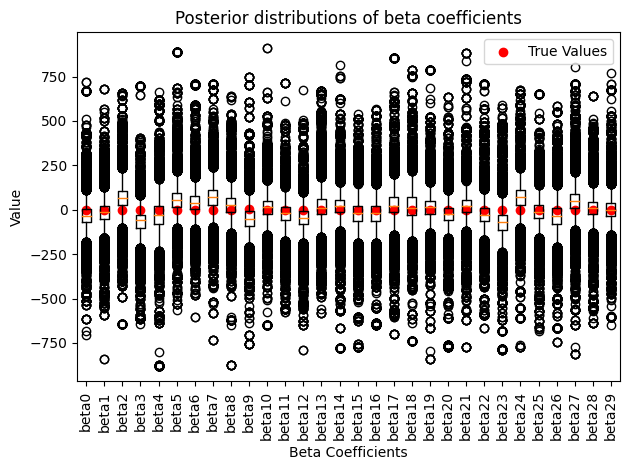

In [33]:
plt.boxplot(
    [result.posterior[f'beta{i}'] for i in range(30)],
    labels=[f'beta{i}' for i in range(30)]
)


x_positions = np.arange(1, 31)  
plt.scatter(x_positions, true_betas, color='red', label='True Values')
plt.xlabel('Beta Coefficients')
plt.xticks(rotation=90)
plt.title('Posterior distributions of beta coefficients')
plt.ylabel('Value')
plt.tight_layout()
plt.legend()
plt.show()

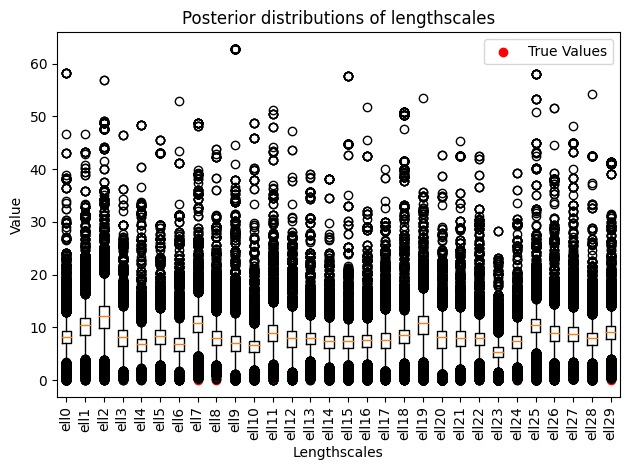

In [35]:
n_features = Xtrain.shape[1]
true_lengthscales = np.zeros(n_features)  # default all 0

for idx, val in zip(active_dims, true_ells):
    true_lengthscales[idx] = val


x_positions = np.arange(1, 31)  
plt.boxplot(
    [result.posterior[f'ell{i}'] for i in range(30)],
    labels=[f'ell{i}' for i in range(30)]
)
plt.scatter(x_positions, true_lengthscales, color='red', label='True Values')
plt.xlabel('Lengthscales')
plt.xticks(rotation=90)
plt.title('Posterior distributions of lengthscales')
plt.ylabel('Value')
plt.tight_layout()
plt.legend()
plt.show()